# 04 - Results and Figures

This notebook analyzes the simulated measurement databases generated in `02_generate_measurements.ipynb` and the Fisher-information results generated in `03_fisher_information.ipynb`.

The analysis examines:

- the distribution of scatterer parameters in the simulation database
- estimator failure as a function of scatterer size and SNR
- estimation RMSE for the first four statistical moments
- differences between fourth- and sixth-order spectral fits
- differences between discrete and Gaussian-mixture scatterers
- estimator RMSE relative to the Cramer-Rao lower bound
- conditioning of the Fisher information matrix

## Inputs

- `delta_database.csv`
- measurement databases in `data/returns/`
- CRLB databases in `data/crlb/`

No new simulation databases are generated by this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
ROOT        = Path.cwd()
RETURNS_DIR = ROOT / "data" / "returns"
CRLB_DIR    = ROOT / "data" / "crlb"

if not RETURNS_DIR.is_dir():
    raise FileNotFoundError("Return databases not found. Run 02_generate_measurements.ipynb first.")

if not CRLB_DIR.is_dir():
    raise FileNotFoundError("CRLB databases not found. Run 03_fisher_information.ipynb first.")

## Scatterer Database Statistics

The following plots summarize the distribution of true statistical moments represented in the discrete-scatterer simulation database.

The standard deviation is converted from round-trip delay units to one-way range units by dividing by two. Thus the plotted range standard deviation $\sigma_x$ is expressed in units of $c/B$.

In [4]:
DELTA_DB        = ROOT / "delta_database.csv"
scatterers      = pd.read_csv(DELTA_DB)

In [5]:
for moment in ["mean", "std", "skew", "kurtosis"]:
# print the mean and std dev of each column
    print(f'{moment} mean:', scatterers[moment].mean())
    print(f'{moment} std dev:', scatterers[moment].std())
    print('')

mean mean: -0.010000000000000002
mean std dev: 0.14001854966417787

std mean: 0.20551254835208532
std std dev: 0.0846558885373308

skew mean: 7.603365128226719e-18
skew std dev: 1.413028956725272

kurtosis mean: 3.5358093893386866
kurtosis std dev: 3.504840941070932



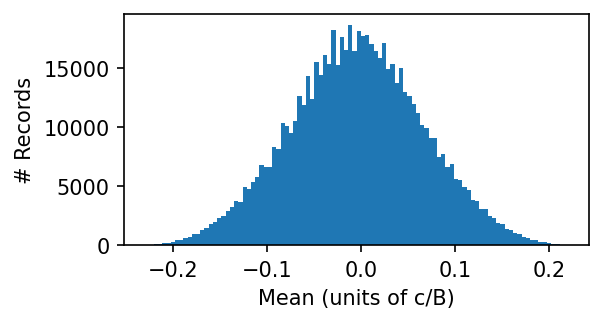

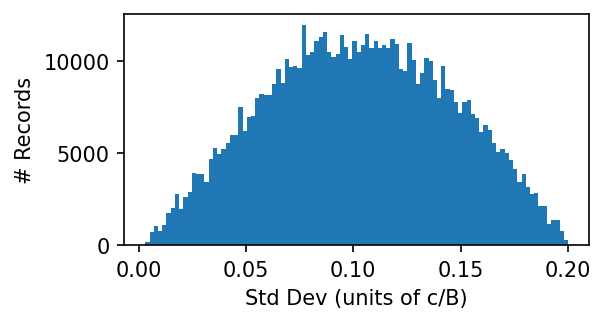

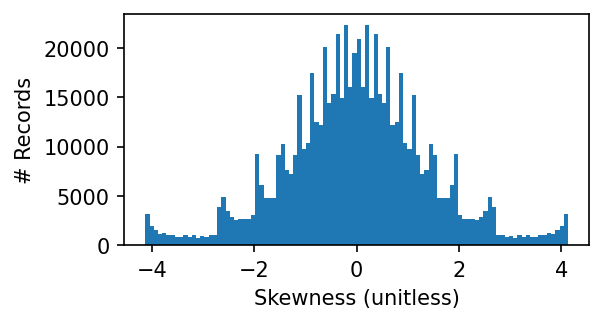

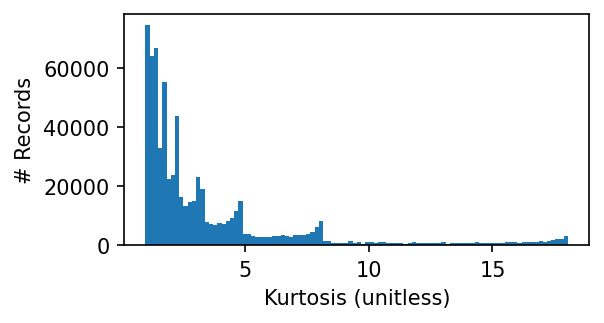

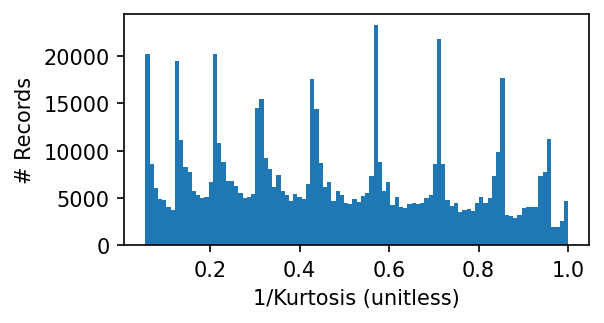

In [8]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (4, 2)

# divide by two to show spatial units rather than round-trip temporal units
plt.hist(scatterers['mean']/2, bins=100)
plt.xlabel('Mean (units of c/B)')
plt.ylabel('# Records')
plt.show()

# divide by two to show spatial units rather than round-trip temporal units
plt.hist(scatterers['std']/2, bins=100)
plt.xlabel('Std Dev (units of c/B)')
plt.ylabel('# Records')
plt.show()

plt.hist(scatterers['skew'], bins=100)
plt.xlabel('Skewness (unitless)')
plt.ylabel('# Records')
plt.show()

plt.hist(scatterers['kurtosis'], bins=100)
plt.xlabel('Kurtosis (unitless)')
plt.ylabel('# Records')
plt.show()

plt.hist(scatterers['inv_kurt'], bins=100)
plt.xlabel('1/Kurtosis (unitless)')
plt.ylabel('# Records')
plt.show()

## Spectral-Moment Estimation Results

In [10]:
def plot_moment_row(axs, data_dir, curves, row_label='', bin_width=0.01, legend=False):
    moments = ['mean', 'std', 'skew', 'kurtosis']
    preds   = ['spectral_mean_pred', 'spectral_std_pred', 'spectral_skew_pred', 'spectral_kurt_pred']
    titles  = ['mean', 'std dev', 'skewness', 'kurtosis']
    crlb    = ['crlb_mean', 'crlb_std', 'crlb_skew', 'crlb_kurtosis']
    crlb_A  = ['crlb_mean_with_intercept', 'crlb_std_with_intercept', 'crlb_skew_with_intercept', 'crlb_kurtosis_with_intercept']
    for curve in curves:
        df                      = pd.read_csv(data_dir / curve['file'])
        df['std_bin']           = pd.cut(df['std'], np.arange(0, df['std'].max() + bin_width, bin_width))
        for ax, moment, pred, title, c0, cA in zip(axs, moments, preds, titles, crlb, crlb_A):
            g                   = df.groupby('std_bin', observed=True)
            x                   = g['std'].mean() / 2
            if curve['kind'] == 'rmse':
                df['_err2']     = (df[pred] - df[moment])**2
                y               = np.sqrt(g['_err2'].mean())
            elif curve['kind'] == 'crlb':
                y               = np.sqrt(g[c0].mean())
            elif curve['kind'] == 'crlb_A':
                y               = np.sqrt(g[cA].mean())
            ax.plot(x, y, label=curve['label'])
            ax.set_yscale('log')
            ax.set_ylabel(row_label)
            ax.legend(loc='upper right')

def plot_moment_grid(data_dir, row_values, curve_builder, title, subtitles, bin_width=0.01, figsize=(15, 15), by_cols=False):
    plt.rcParams['figure.dpi']      = 200
    fig                             = plt.figure(figsize=figsize, layout='constrained')
    if by_cols:
        subfigs                     = fig.subfigures(1, len(row_values), wspace=0.03)
    else:
        subfigs                     = fig.subfigures(len(row_values), 1, hspace=0.03)
    axs                             = []
    fig.suptitle(title, fontsize=18)
    for subfig, row_val, title in zip(subfigs, row_values, subtitles):
        subfig.suptitle(title, fontsize=14)
        if by_cols:
            ax                      = subfig.subplots(4, 1)
        else:
            ax                      = subfig.subplots(1, 4)
        axs.append(ax)
    for i, row in enumerate(row_values):
        plot_moment_row(axs[i], data_dir, curve_builder(row), row_label=f'RMSE', bin_width=bin_width)
    plt.show()

### Estimator Failure Rate

Shows the fraction of records for which the fitted second raw moment implies a nonphysical variance.

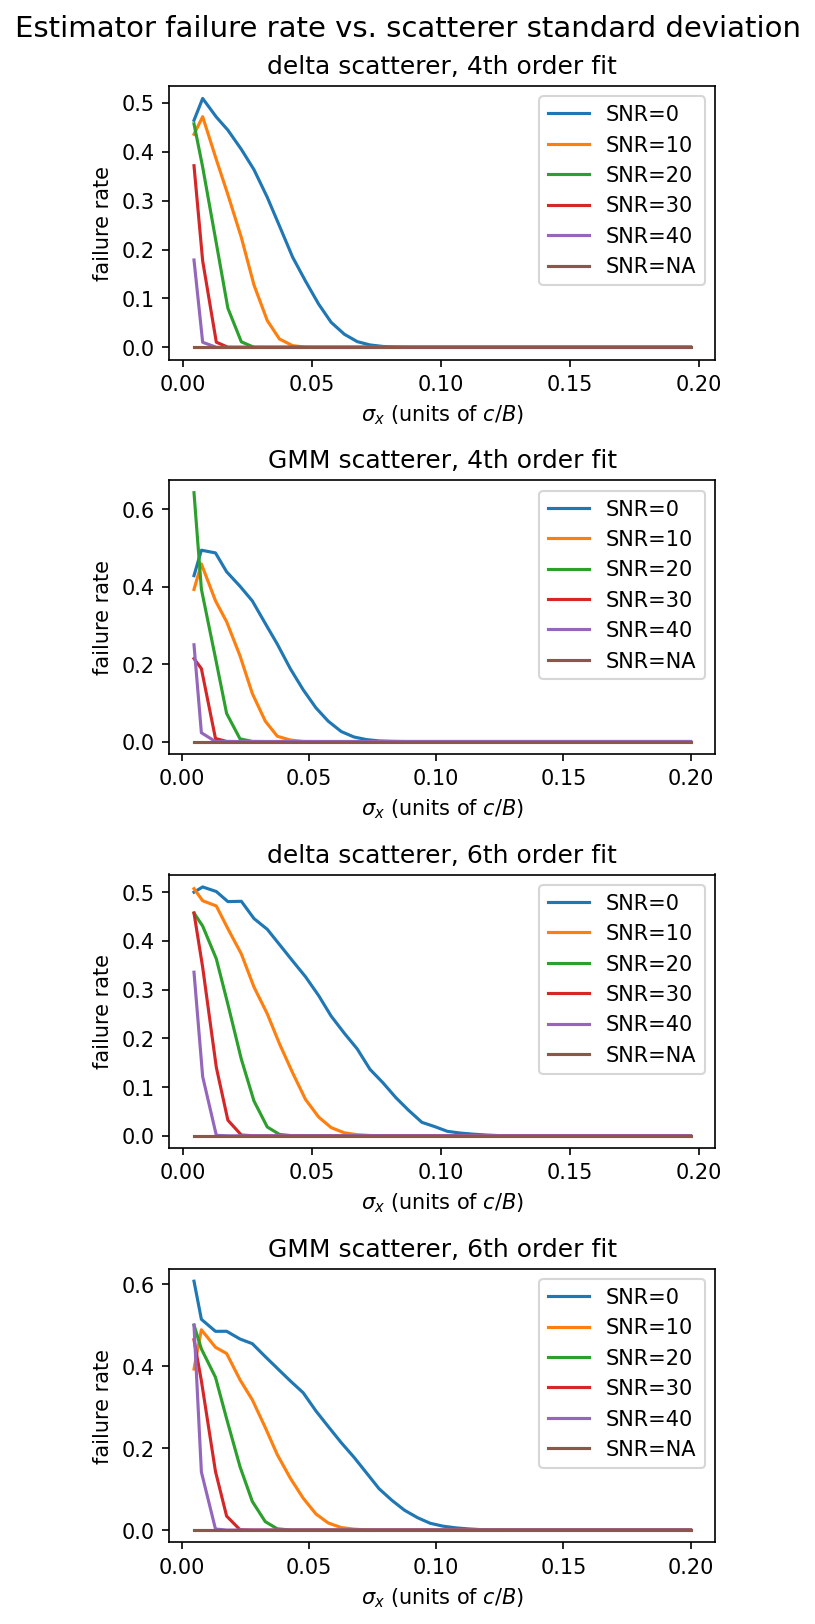

In [11]:
df_array                    = []
plt.rcParams['figure.dpi']  = 150
fig, axs                    = plt.subplots(4, 1, figsize=(4.5, 11))
fig.suptitle('Estimator failure rate vs. scatterer standard deviation', fontsize=14)

for order_val, order in enumerate([4, 6]):
    for scatter_val, scatterer in enumerate(['delta', 'gmm']):
        row                 = 2*order_val + scatter_val
        ax                  = axs[row]
        for snr in [0, 10, 20, 30, 40, 'NA']:
            filename        = f'{scatterer}_discrete_len20_snr{snr}_order{order}.csv'
            df              = pd.read_csv(RETURNS_DIR / filename, usecols=['std', 'spectral_var_pred', 'spectral_std_pred'])
            df['failed']    = df['spectral_var_pred'] <= 0
            df['std_bin']   = pd.cut(df['std'], np.arange(0, df['std'].max() + 0.01, 0.01))
            g               = df.groupby('std_bin', observed=True)
            x               = g['std'].mean() / 2
            ax.plot(x, g['failed'].mean(), label=f'SNR={snr}')
        ax.set_title(f'{scatterer.replace('gmm', 'GMM')} scatterer, {order}th order fit')
        ax.set_xlabel(r'$\sigma_x$ (units of $c/B$)')
        ax.set_ylabel('failure rate')
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Dependence on SNR

More noise not only worsens predictions, but also dramatically affects at what size (std dev) distribution higher-order moments can be accurately predicted.

At large enough distributions and/or low enough noise, bias from nth-order fit plays a larger role than variance from noise.

In [13]:
def compare_moment_errors_vs_std_bins(data_dir, df_arrays, bin_width=0.01, error_cols=None, bin_col='std',
                                      label_spot=-1, title_name=None, numrows=2, numcols=4, size=(15, 5)):
    if error_cols is None:
        error_cols                  = ['mean_error', 'std_error', 'skew_error', 'kurtosis_error']
    required_cols                   = [bin_col] + error_cols

    plt.rcParams['figure.dpi']      = 150
    fig                             = plt.figure(figsize=size, layout='constrained')
    subfigs                         = fig.subfigures(numrows, 1, hspace=0.05)
    row_titles                      = ['4th-order', '6th-order']

    for row, subfig in enumerate(subfigs):
        subfig.suptitle(f'Moment estimation RMSE for delta database, {row_titles[row]} spectral polynomial fit',
                        fontsize=14)

    axs1                            = subfigs[0].subplots(1, numcols)
    axs2                            = subfigs[1].subplots(1, numcols)
    axs                             = [axs1, axs2]

    for df_name in df_arrays:
        df                          = pd.read_csv(data_dir / df_name)
        df_label                    = df_name.split('_')[label_spot].replace('.csv', '')

        for moment in ["mean", "std", "skew"]:
            df[f"{moment}_error"]   = (df[moment] - df[f"spectral_{moment}_pred"])**2
        df['kurtosis_error']        = (df['kurtosis'] - df['spectral_kurt_pred'])**2

        df                          = df[required_cols]
        max_bin_val                 = df[bin_col].max()
        bins                        = np.arange(0, max_bin_val + bin_width, bin_width)
        df['std_bin']               = pd.cut(df[bin_col], bins=bins, include_lowest=True)
        cols_to_agg                 = df.columns.difference(['std_bin'])
        binned_data                 = df.groupby('std_bin', observed=True)[cols_to_agg].agg(['mean', 'std'])

        if "order4" in df_name:
            row = 0
        elif "order6" in df_name:
            row = 1

        for col, error_col in enumerate(error_cols):
            x                       = binned_data[(bin_col, 'mean')]
            y                       = binned_data[(error_col, 'mean')]

            axs[row][col].plot(x/2, np.sqrt(y), label=df_label.replace('snr', 'snr ').replace('order', 'order '))
            axs[row][col].set_yscale('log')
            axs[row][col].set_xlabel(r'$\sigma_x$ (units of $c/B$)', fontsize=12)
            axs[row][col].set_ylabel(f'{error_col.replace('_', ' ').replace('std', 'std dev').replace('skew', 'skewness').replace('error', 'RMSE')}', fontsize=12)
            axs[row][col].legend()

    plt.show()

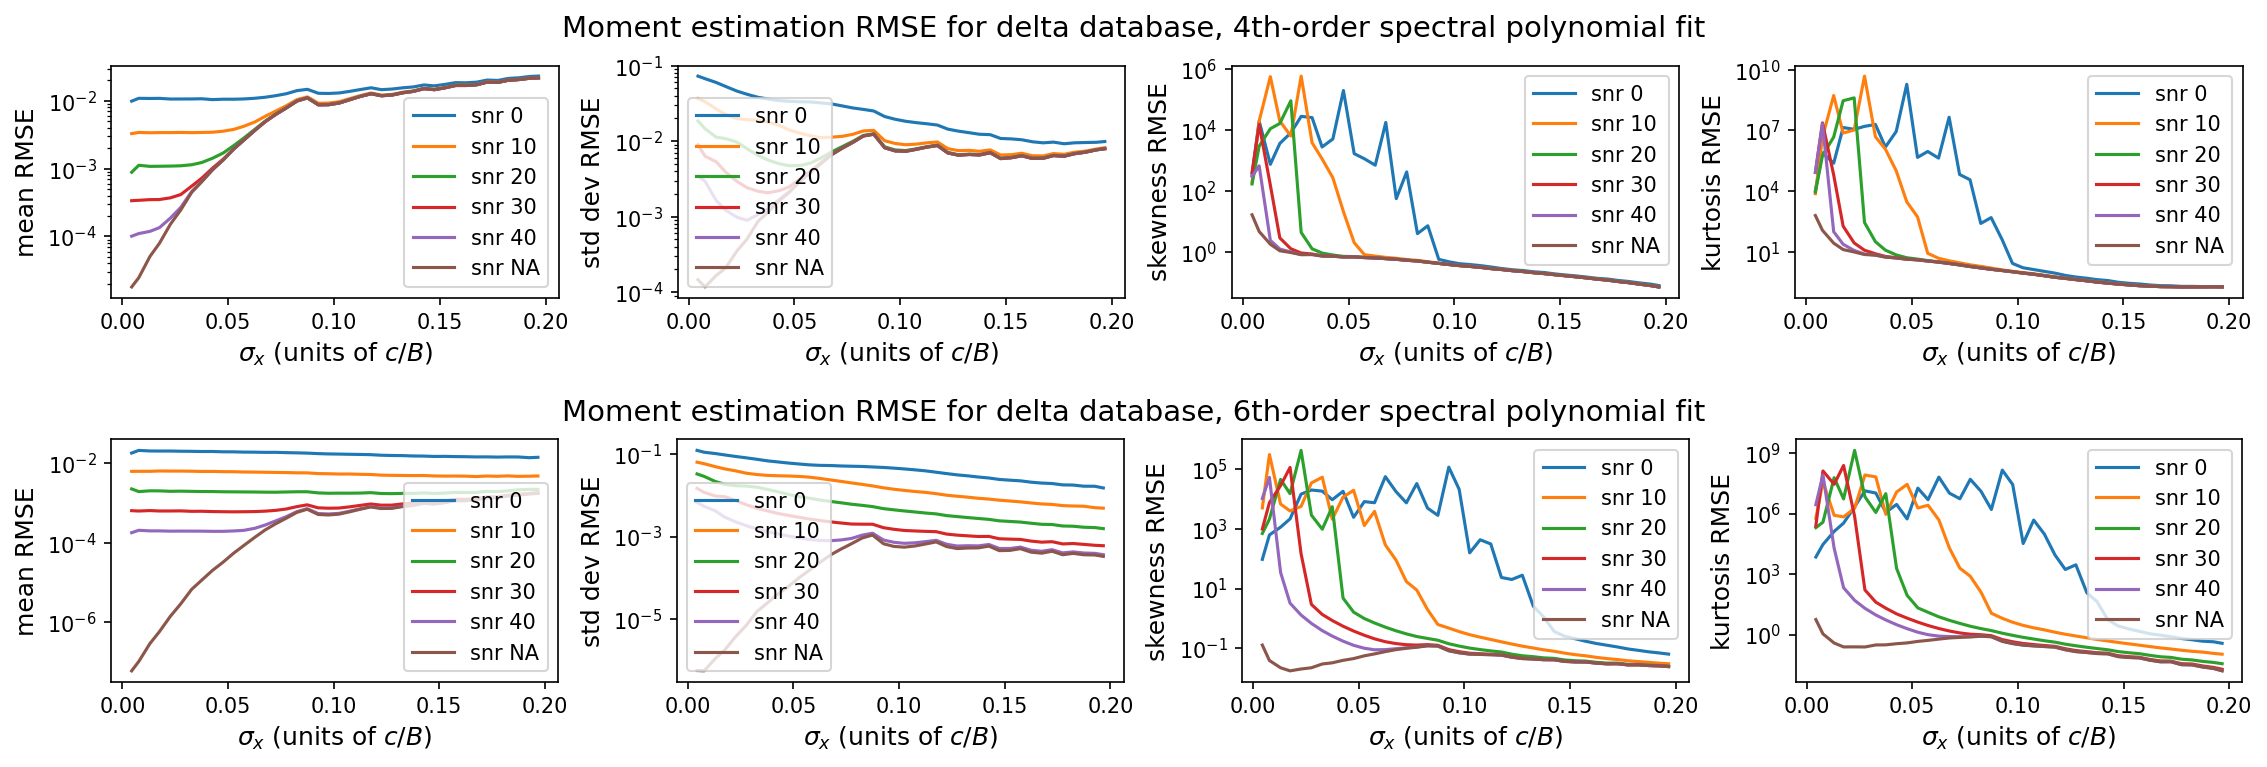

In [14]:
df_array        = []
for order in [4, 6]:
    title_name  = f'delta_order{order}'
    for snr in [0, 10, 20, 30, 40, 'NA']:
        df_array.append(f'delta_discrete_len20_snr{snr}_order{order}.csv')

compare_moment_errors_vs_std_bins(RETURNS_DIR, df_array, label_spot=3, title_name=title_name)

### Fourth- vs. Sixth-Order Fits

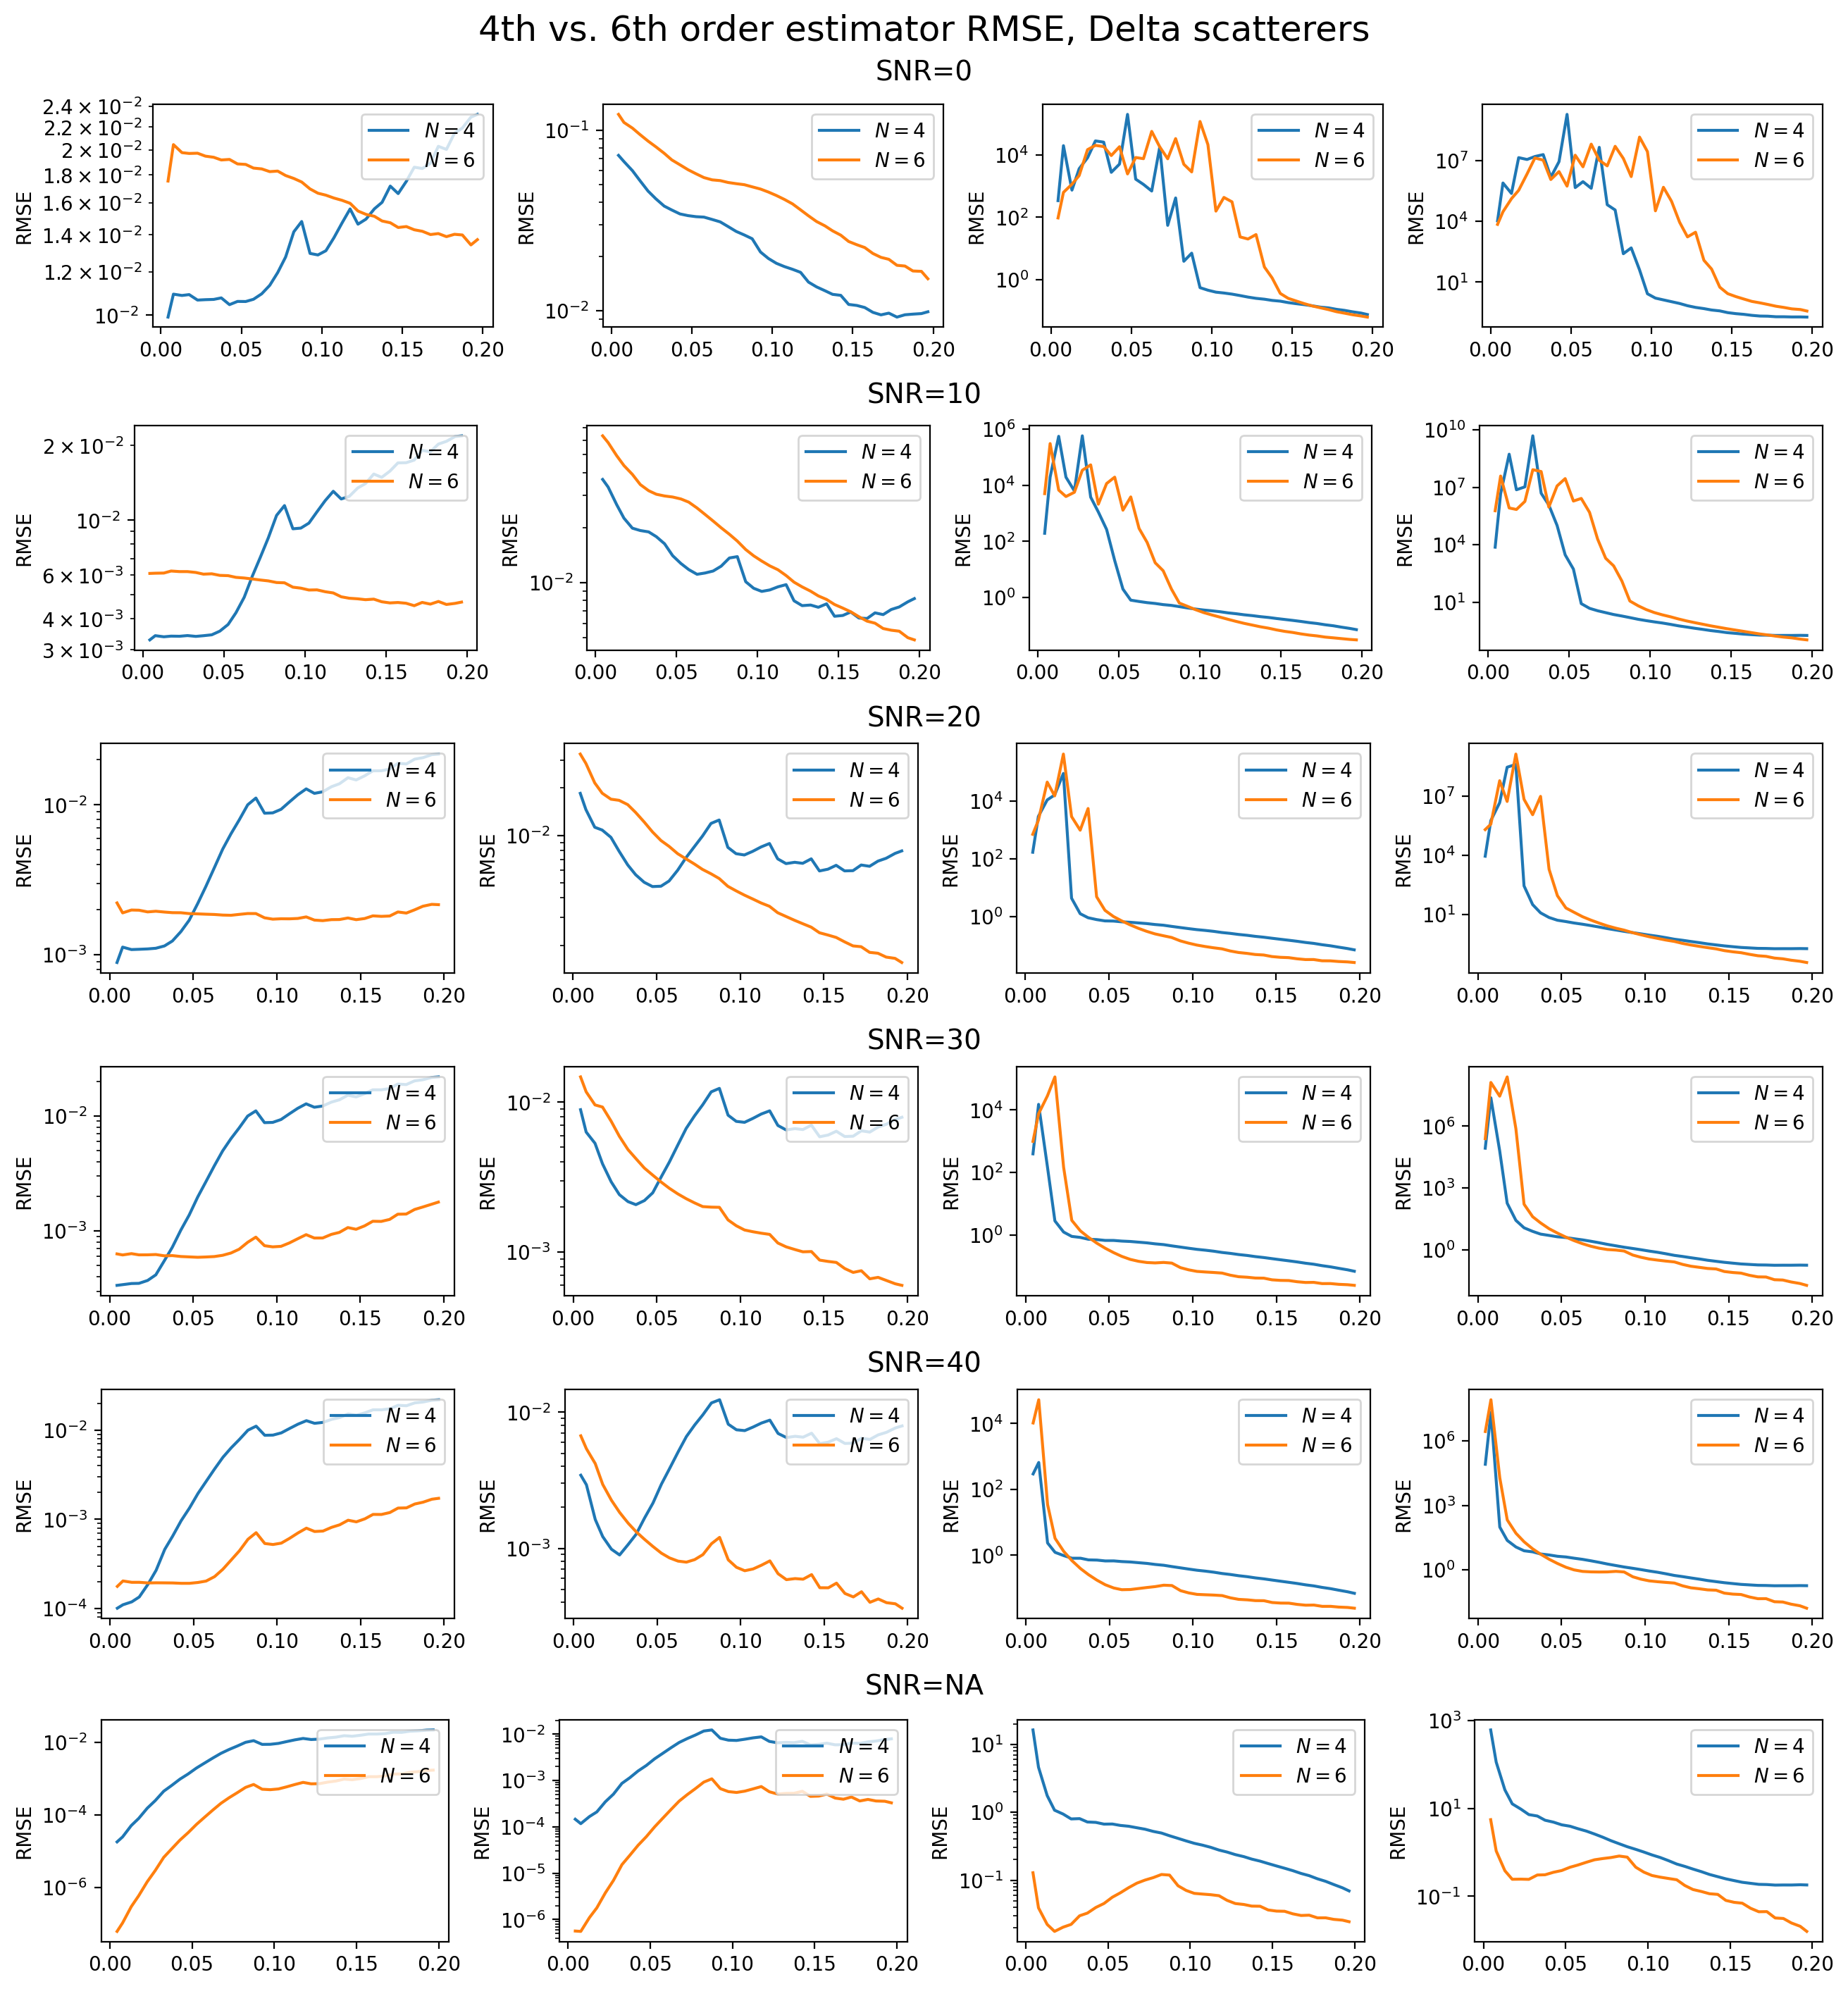

In [15]:
row_vals    = [0, 10, 20, 30, 40, 'NA']
titles      = [f'SNR={i}' for i in row_vals]

plot_moment_grid(
    RETURNS_DIR,
    figsize         = (13, 14),
    row_values      = row_vals,
    title           = '4th vs. 6th order estimator RMSE, Delta scatterers',
    subtitles       = titles,
    curve_builder   = lambda snr: [{'file':f'delta_discrete_len20_snr{snr}_order4.csv', 'label':r'$N=4$', 'kind':'rmse'},
                                   {'file':f'delta_discrete_len20_snr{snr}_order6.csv', 'label':r'$N=6$', 'kind':'rmse'}]
    )

### Discrete vs. GMM Scatterers, 4th Order

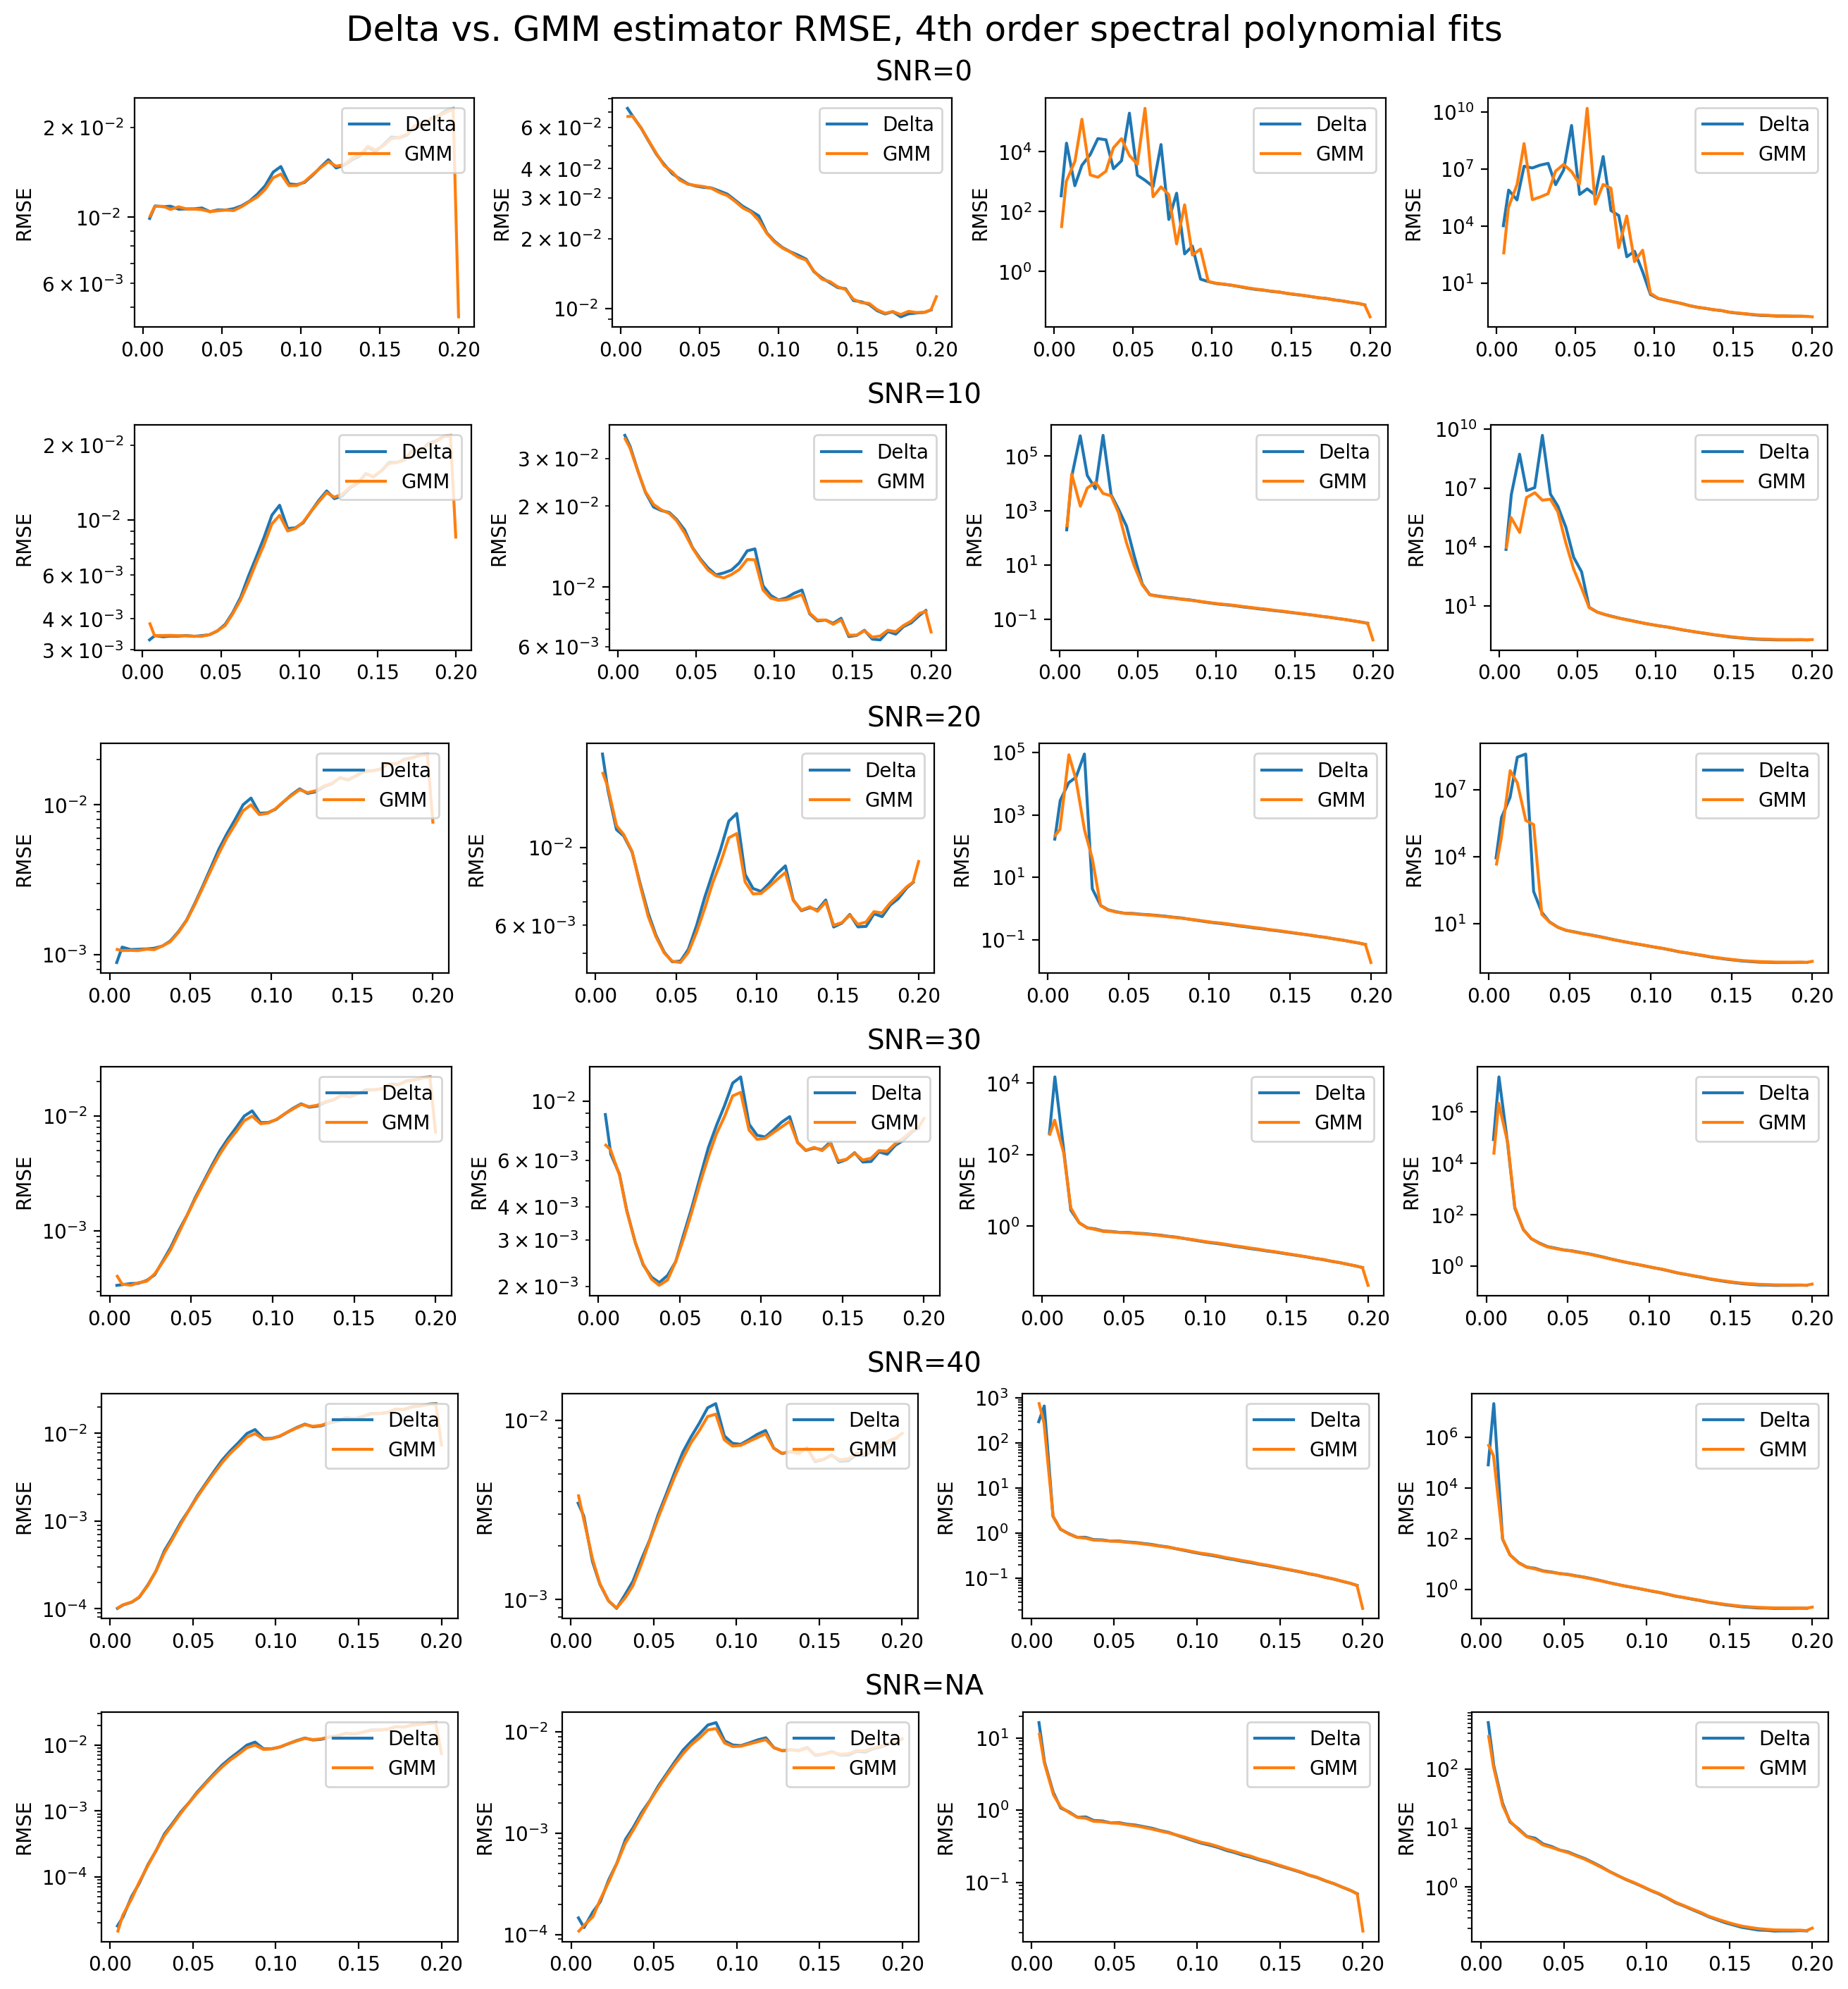

In [16]:
row_vals    = [0, 10, 20, 30, 40, 'NA']
titles      = [f'SNR={i}' for i in row_vals]

plot_moment_grid(
    RETURNS_DIR,
    figsize         = (13, 14),
    row_values      = row_vals,
    title           = 'Delta vs. GMM estimator RMSE, 4th order spectral polynomial fits',
    subtitles       = titles,
    curve_builder   = lambda snr: [{'file':f'delta_discrete_len20_snr{snr}_order4.csv', 'label':'Delta', 'kind':'rmse'},
                                   {'file':f'gmm_discrete_len20_snr{snr}_order4.csv', 'label':'GMM', 'kind':'rmse'}]
    )

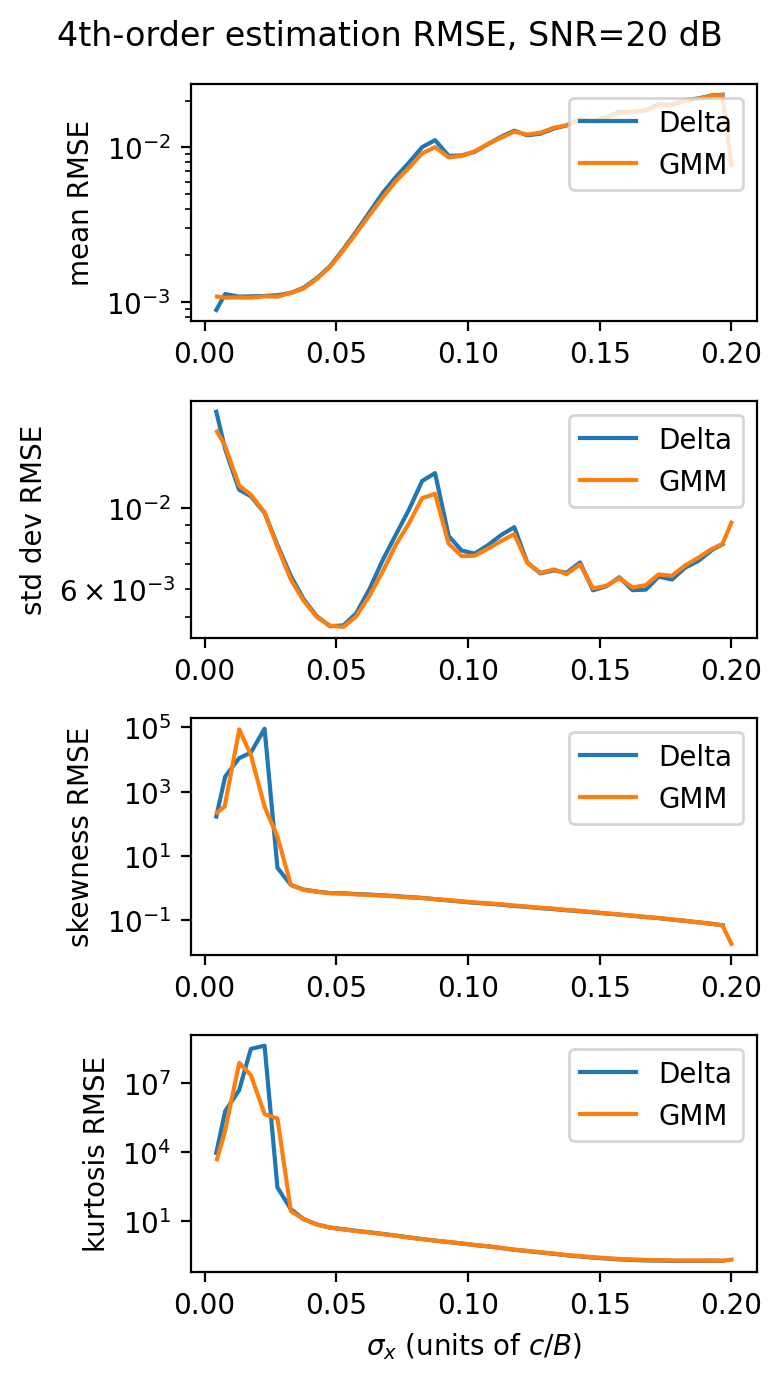

In [17]:
fig, axs    = plt.subplots(4, 1, figsize=(4, 7))
order       = 4
snr         = 20
curves      = [{'file':f'delta_discrete_len20_snr{snr}_order{order}.csv', 'label':'Delta', 'kind':'rmse'},
               {'file':f'gmm_discrete_len20_snr{snr}_order{order}.csv', 'label':'GMM', 'kind':'rmse'}]

plot_moment_row(axs, RETURNS_DIR, curves)
axs[0].set_ylabel('mean RMSE')
axs[1].set_ylabel('std dev RMSE')
axs[2].set_ylabel('skewness RMSE')
axs[3].set_ylabel('kurtosis RMSE')
axs[3].set_xlabel(r'$\sigma_x$ (units of $c/B$)')
fig.suptitle('4th-order estimation RMSE, SNR=20 dB')
plt.tight_layout()
plt.show()

### Discrete vs. GMM Scatterers, 6th Order

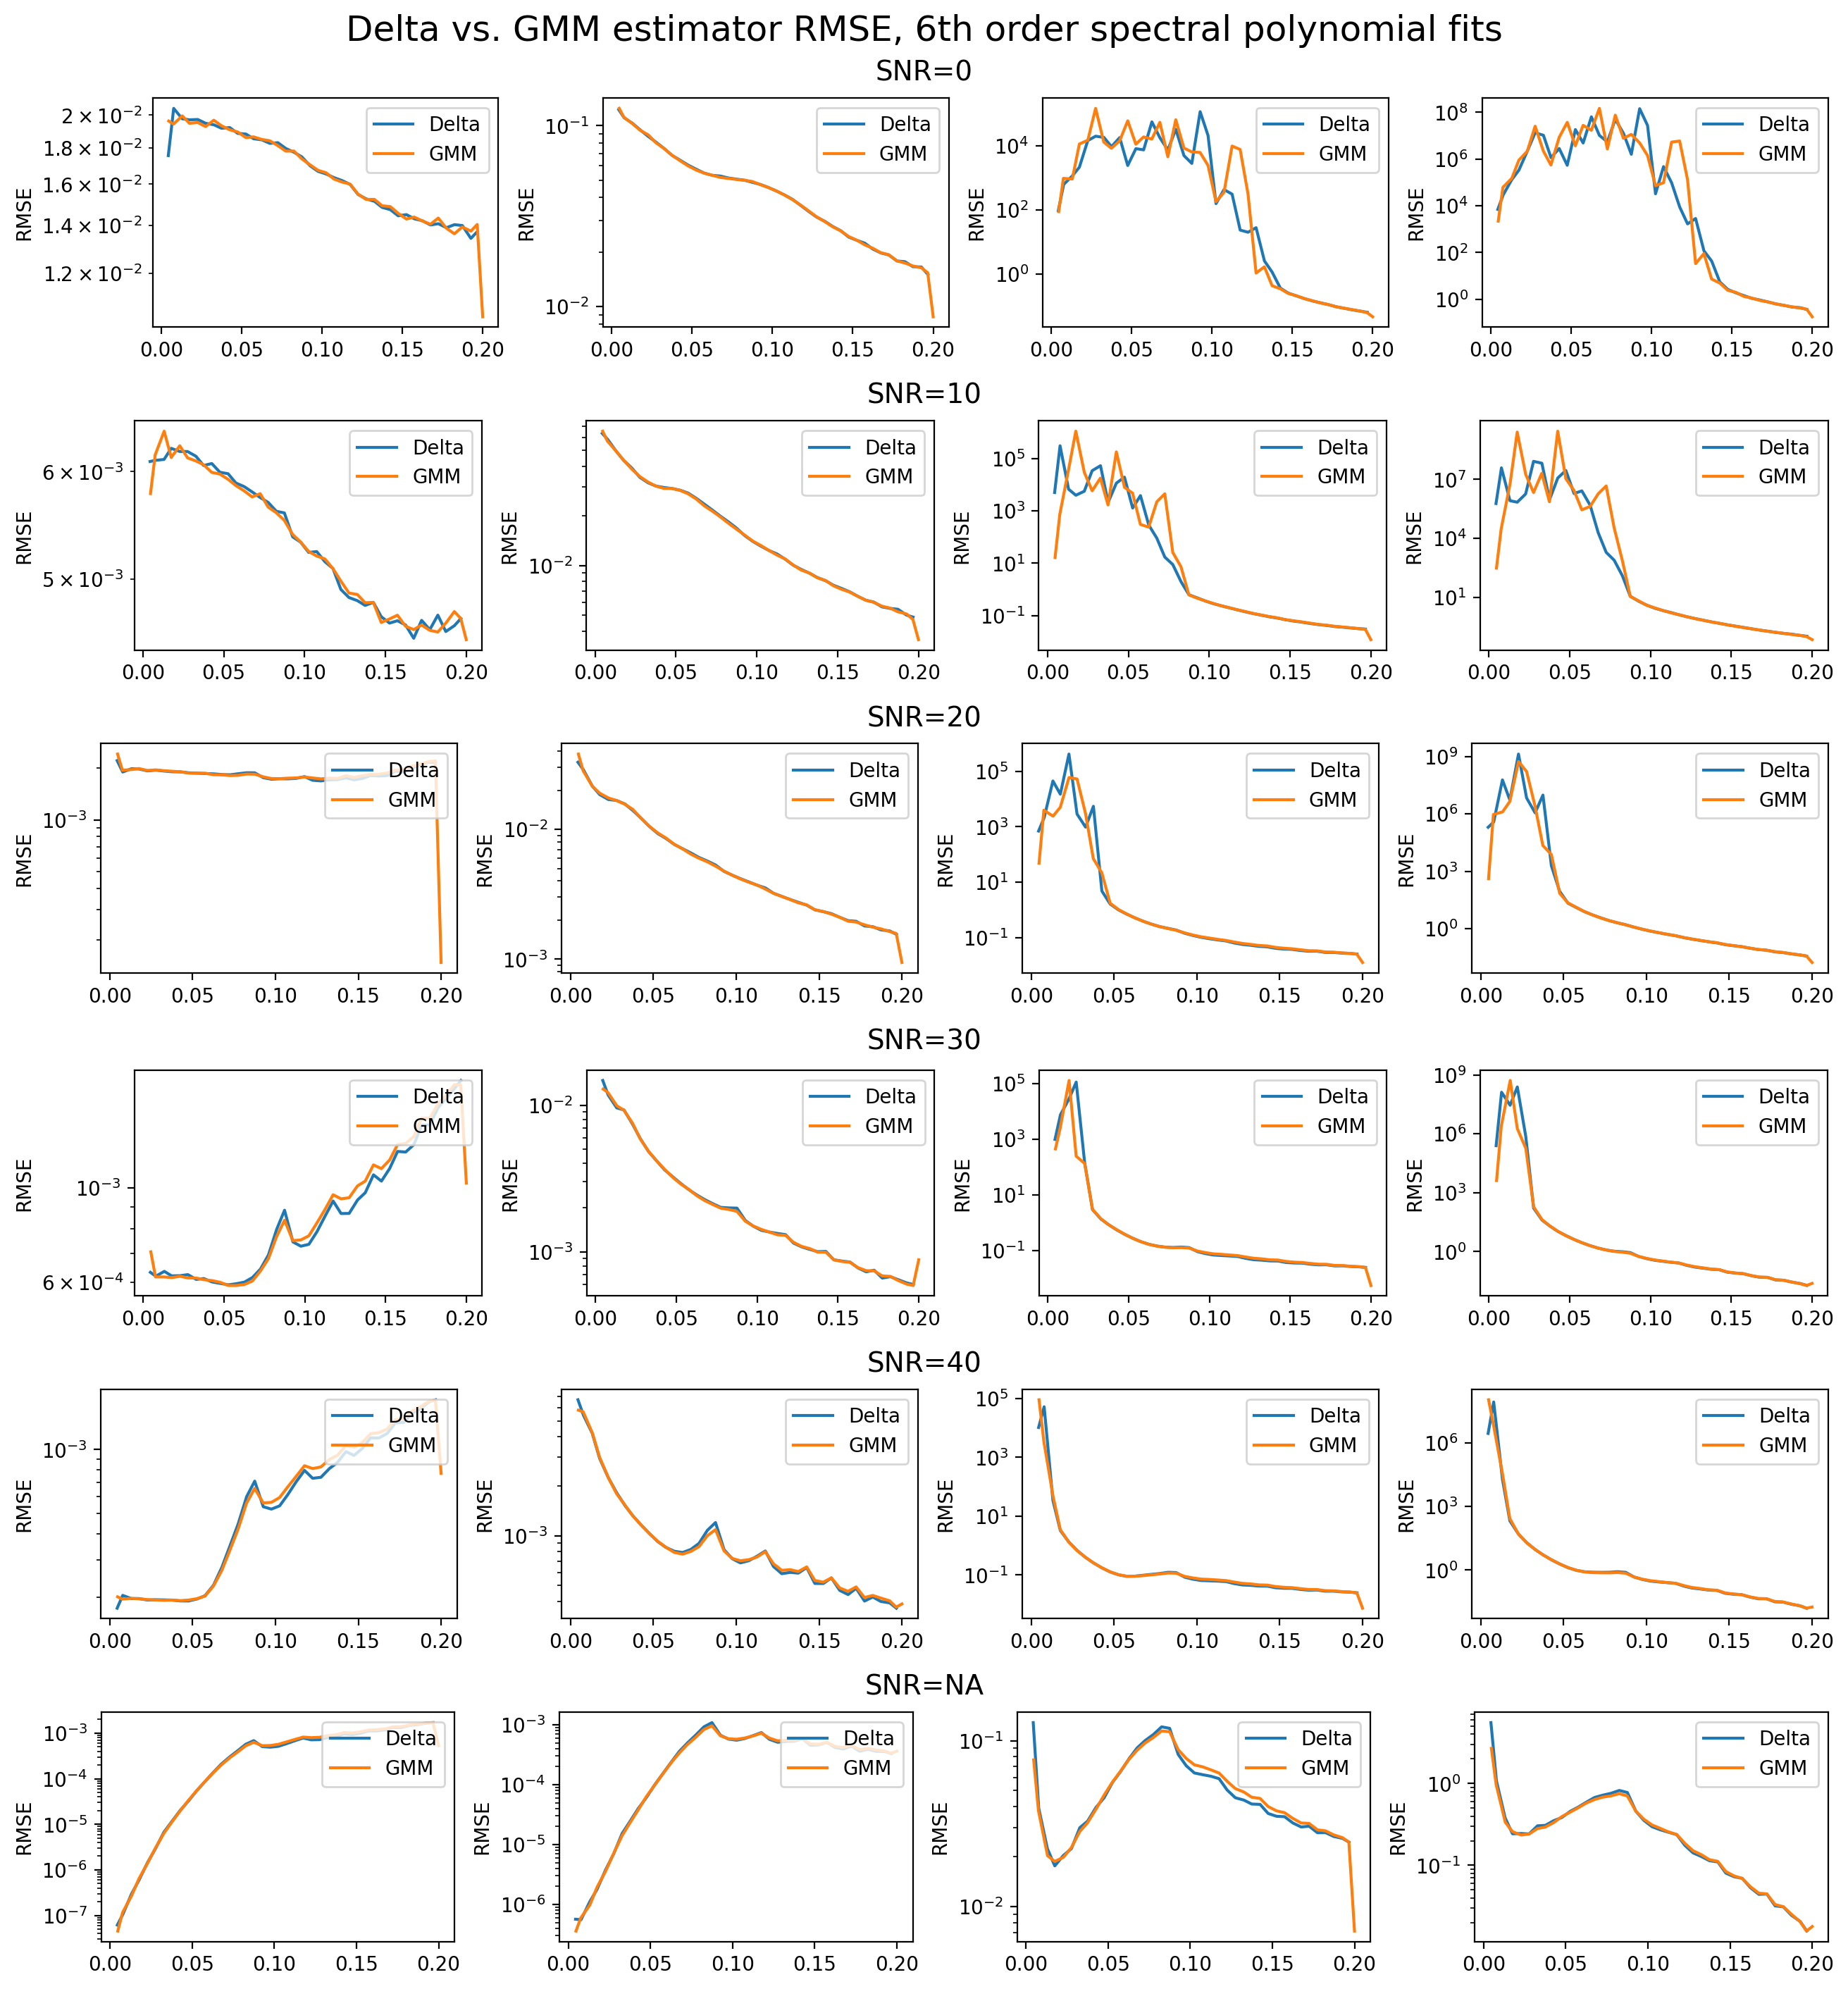

In [18]:
row_vals    = [0, 10, 20, 30, 40, 'NA']
titles      = [f'SNR={i}' for i in row_vals]

plot_moment_grid(
    RETURNS_DIR,
    figsize         = (13, 14),
    row_values      = row_vals,
    title           = 'Delta vs. GMM estimator RMSE, 6th order spectral polynomial fits',
    subtitles       = titles,
    curve_builder   = lambda snr: [{'file':f'delta_discrete_len20_snr{snr}_order6.csv', 'label':'Delta', 'kind':'rmse'},
                                   {'file':f'gmm_discrete_len20_snr{snr}_order6.csv', 'label':'GMM', 'kind':'rmse'}]
    )

## Cramer-Rao Bound Comparison

In [19]:
def compare_moment_errors_to_crlb(data_dir, df_arrays, bin_col='std', bin_width=0.01, error_cols=None, title_name=None,
                                  numrows=2, numcols=4, size=(15, 5.5)):
    if error_cols is None:
        error_cols      = ['mean_sq_error', 'std_sq_error', 'skew_sq_error', 'kurtosis_sq_error']
    crlb_cols           = ['crlb_mean', 'crlb_std', 'crlb_skew', 'crlb_kurtosis']
    crlb_cols2          = ['crlb_mean_with_intercept', 'crlb_std_with_intercept',
                           'crlb_skew_with_intercept', 'crlb_kurtosis_with_intercept']
    required_cols       = [bin_col] + error_cols + crlb_cols + crlb_cols2

    plt.rcParams['figure.dpi']      = 200
    fig                             = plt.figure(figsize=size, layout='constrained')
    subfigs                         = fig.subfigures(numrows, 1, hspace=0.05)
    row_titles                      = ['4th-order', '6th-order']

    if numrows == 1:
        subfigs.suptitle(r'Delta scatterer moment estimation RMSE vs. $\sqrt{CRLB}$, 6th order fit, SNR=20', fontsize=14)
        axs1                            = subfigs.subplots(1, numcols)
        axs                             = [axs1]
    elif numrows == 2:
        subfigs[0].suptitle(r'Delta scatterer moment estimation RMSE vs. $\sqrt{CRLB}$, 4th order fit, SNR=20', fontsize=14)
        subfigs[1].suptitle(r'Delta scatterer moment estimation RMSE vs. $\sqrt{CRLB}$, 6th order fit, SNR=20', fontsize=14)

        axs1                            = subfigs[0].subplots(1, numcols)
        axs2                            = subfigs[1].subplots(1, numcols)
        axs                             = [axs1, axs2]

    for df_name in df_arrays:
        df              = pd.read_csv(data_dir / df_name)
        df_label        = df_name.replace('.csv', '')
        pcs             = df_name.split('_')

        for piece in pcs:
            if 'order' in piece:
                order   = int(piece.replace('order', ''))
            elif 'snr' in piece:
                snr     = int(piece.replace('snr', ''))

        for moment in ['mean', 'std', 'skew']:
            df[f'{moment}_sq_error']    = (df[moment] - df[f'spectral_{moment}_pred'])**2
        df['kurtosis_sq_error']         = (df['kurtosis'] - df['spectral_kurt_pred'])**2

        df              = df[required_cols]
        max_bin_val     = df[bin_col].max()
        bins            = np.arange(0, max_bin_val + bin_width, bin_width)
        df['std_bin']   = pd.cut(df[bin_col], bins=bins, include_lowest=True)
        cols_to_agg     = df.columns.difference(['std_bin'])
        binned_data     = df.groupby('std_bin', observed=True)[cols_to_agg].agg(['mean', 'std', 'median', 'max'])

        if numrows == 1:
            row = 0
        elif "order4" in df_name:
            row = 0
        elif "order6" in df_name:
            row = 1

        for col, moment_name in enumerate(['mean', 'std', 'skew', 'kurtosis']):
            x                       = binned_data[(bin_col, 'mean')]
            y1                      = np.sqrt(binned_data[(f'{moment_name}_sq_error', 'mean')])
            y2                      = np.sqrt(binned_data[(f'crlb_{moment_name}', 'mean')])
            y3                      = np.sqrt(binned_data[(f'crlb_{moment_name}_with_intercept', 'mean')])

            axs[row][col].plot(x/2, y1, label='RMSE')
            axs[row][col].plot(x/2, y2, label=r'$\sqrt{CRLB}$')
            axs[row][col].plot(x/2, y3, label=r'$\sqrt{CRLB}$, nuisance $A$', c='tab:red')
            axs[row][col].set_yscale('log')
            axs[row][col].set_xlabel(r'$\sigma_x$ (units of $c/B)$')
            axs[row][col].set_title(f'{moment_name.replace('std', 'std dev').replace('skew', 'skewness')}')
            axs[row][col].set_ylabel(f'{moment_name.replace('std', 'std dev').replace('skew', 'skewness')} uncertainty')
            axs[row][col].legend()

    plt.show()

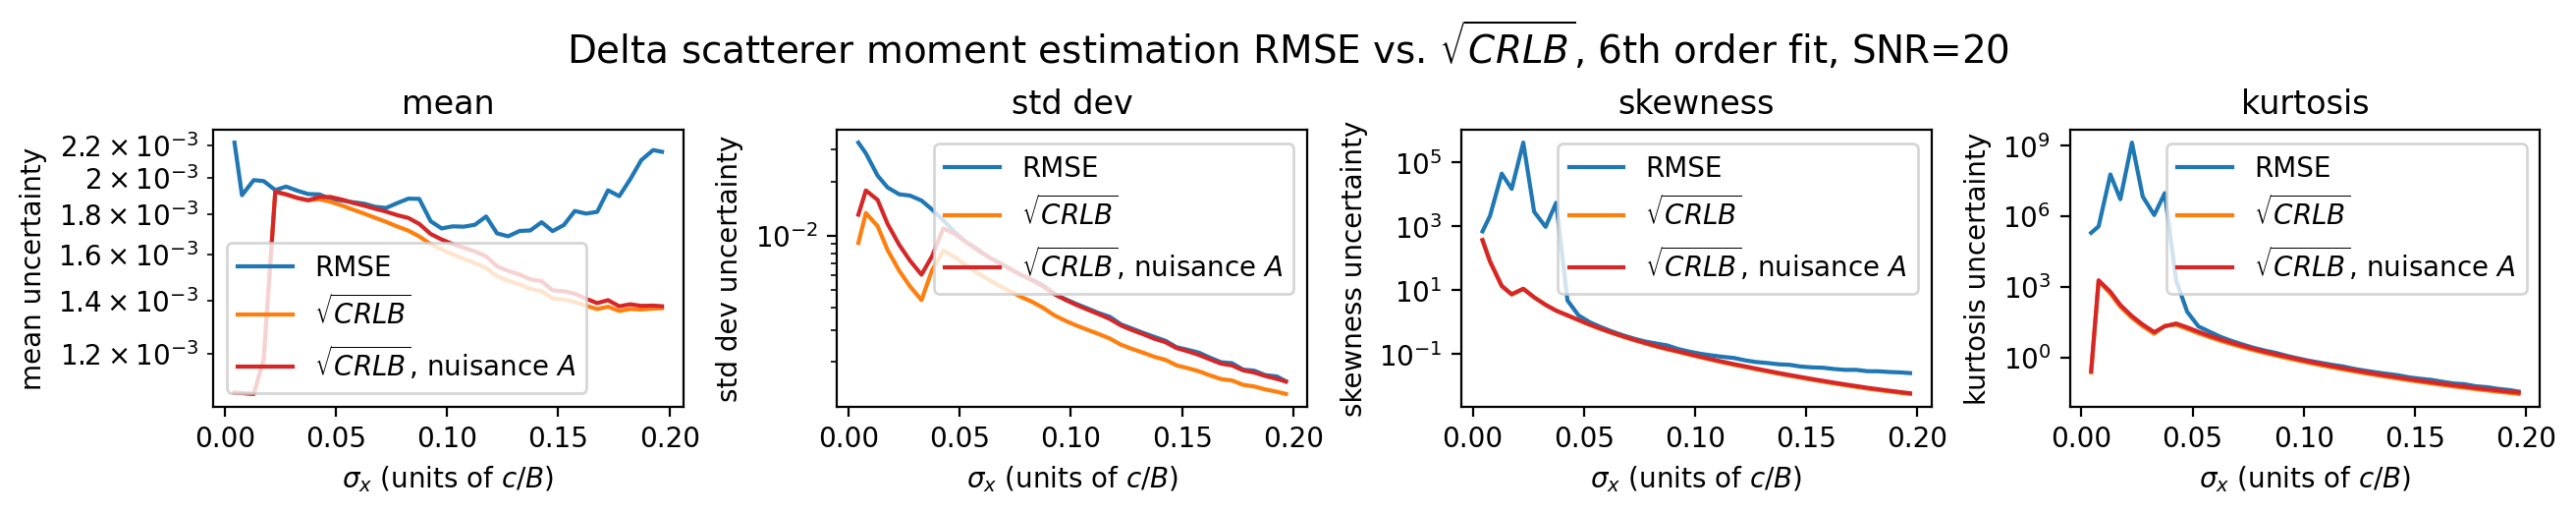

In [20]:
df_array    = []
scatterer   = 'delta'
order       = 6
snr         = 20
title_name  = f'Delta scatterer moment estimation RMSE vs. CRLB, {order}th order fit, SNR={snr}'

df_array.append(f'delta_discrete_len20_snr{snr}_order6_crlb.csv')

compare_moment_errors_to_crlb(CRLB_DIR, df_array, title_name=title_name, numrows=1, numcols=4, size=(13, 2.5))

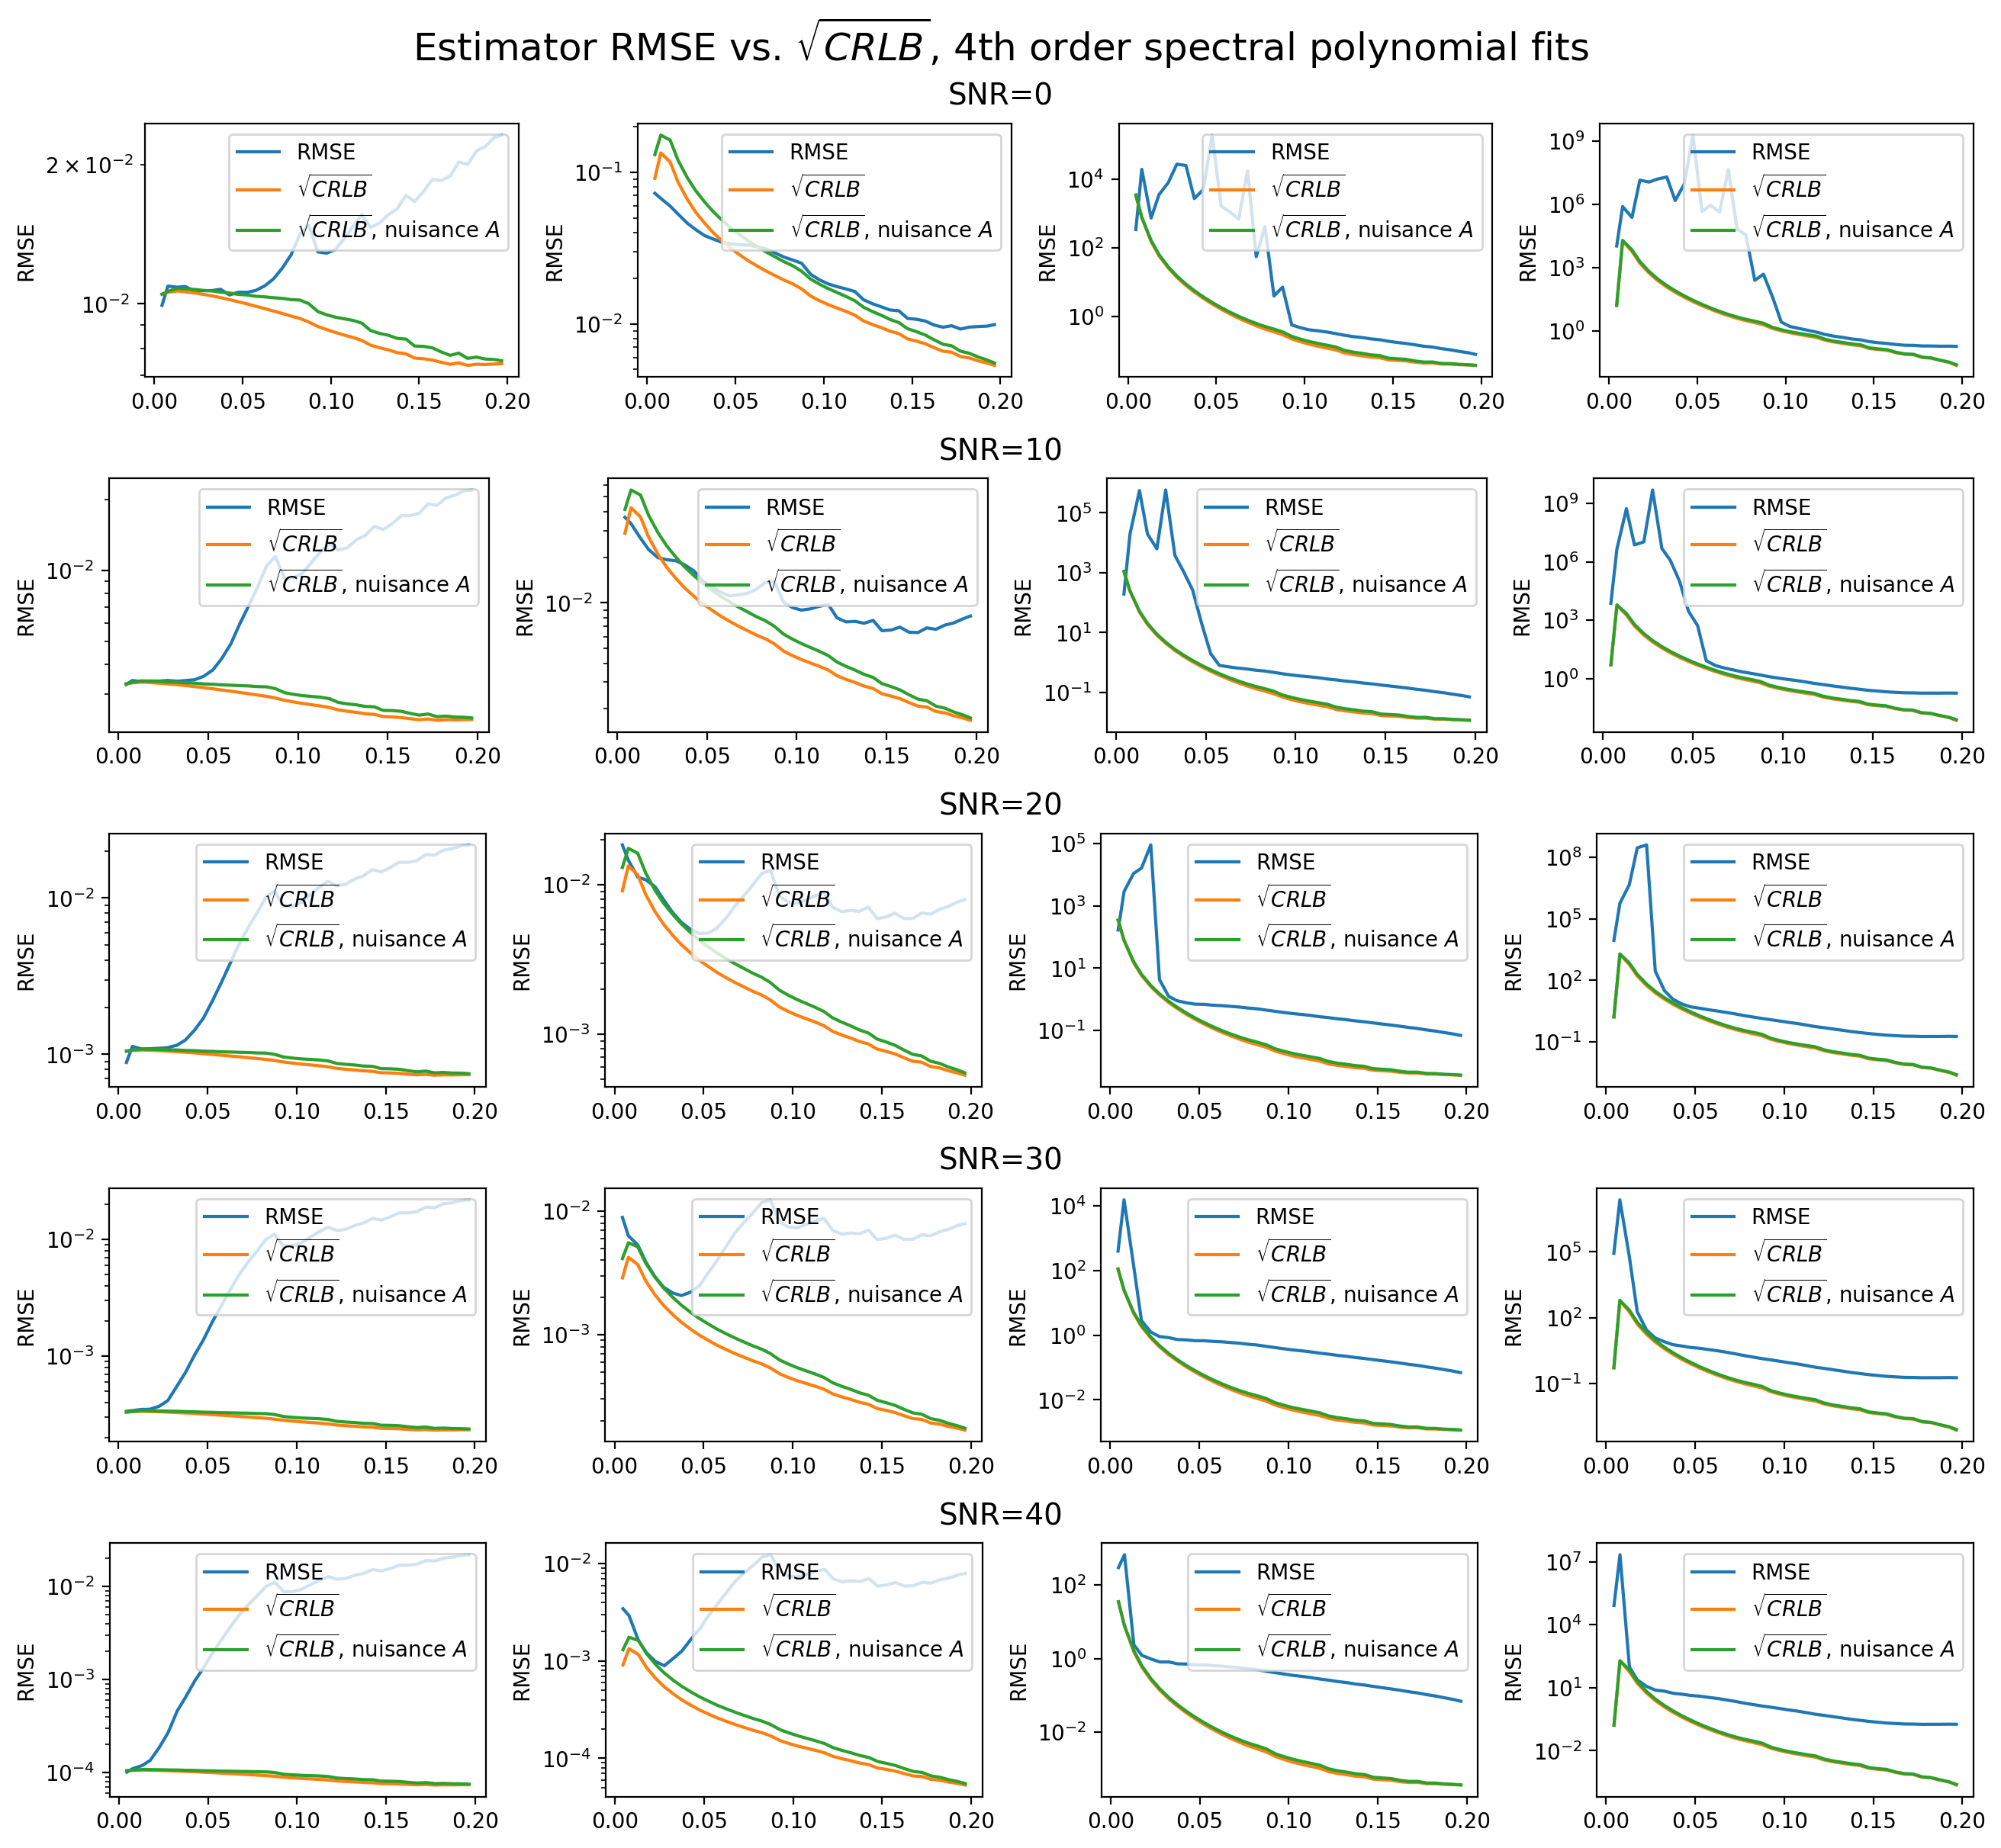

In [21]:
row_vals    = [0, 10, 20, 30, 40]
titles      = [f'SNR={i}' for i in row_vals]
order       = 4

plot_moment_grid(
    CRLB_DIR,
    figsize         = (13, 12),
    row_values      = row_vals,
    title           = r'Estimator RMSE vs. $\sqrt{CRLB}$,' + f' {order}th order spectral polynomial fits',
    subtitles       = titles,
    curve_builder   = lambda snr: [{'file':f'delta_discrete_len20_snr{snr}_order{order}_crlb.csv', 'label':'RMSE', 'kind':'rmse'},
                                   {'file':f'delta_discrete_len20_snr{snr}_order{order}_crlb.csv', 'label':r'$\sqrt{CRLB}$', 'kind':'crlb'},
                                   {'file':f'delta_discrete_len20_snr{snr}_order{order}_crlb.csv', 'label':r'$\sqrt{CRLB}$, nuisance $A$', 'kind':'crlb_A'}]
    )

## Fisher-Information Conditioning

In [22]:
def fim_condition(data_dir, df_array, orders, bin_col='std', bin_width=0.01, error_cols=None, title_name=None):
    if error_cols is None:
        error_cols      = ['crlb_fim_cond']
    required_cols       = [bin_col] + error_cols

    plt.rcParams['figure.dpi']      = 300
    fig, ax                         = plt.subplots(1, 1, figsize=(4, 3))

    for df_name, order in zip(df_array, orders):
        df                              = pd.read_csv(data_dir / df_name)
        df_label                        = df_name.replace('.csv', '')
        df                              = df[required_cols]
        max_bin_val                     = df[bin_col].max()
        bins                            = np.arange(0, max_bin_val + bin_width, bin_width)
        df['std_bin']                   = pd.cut(df[bin_col], bins=bins, include_lowest=True)
        cols_to_agg                     = df.columns.difference(['std_bin'])
        binned_data                     = df.groupby('std_bin', observed=True)[cols_to_agg].agg(['mean', 'median'])
        x                               = binned_data[(bin_col, 'mean')]
        y1                              = binned_data[(f'crlb_fim_cond', 'median')]

        ax.plot(x/2, y1, label=f'{order}th order')

    ax.set_yscale('log')
    ax.set_xlabel(r'$\sigma_x$ (units of c/B)')
    ax.set_ylabel('FIM condition')
    ax.legend()
    fig.suptitle('FIM condition vs. scatterer std dev, 4th vs. 6th order')
    plt.tight_layout()
    plt.show()

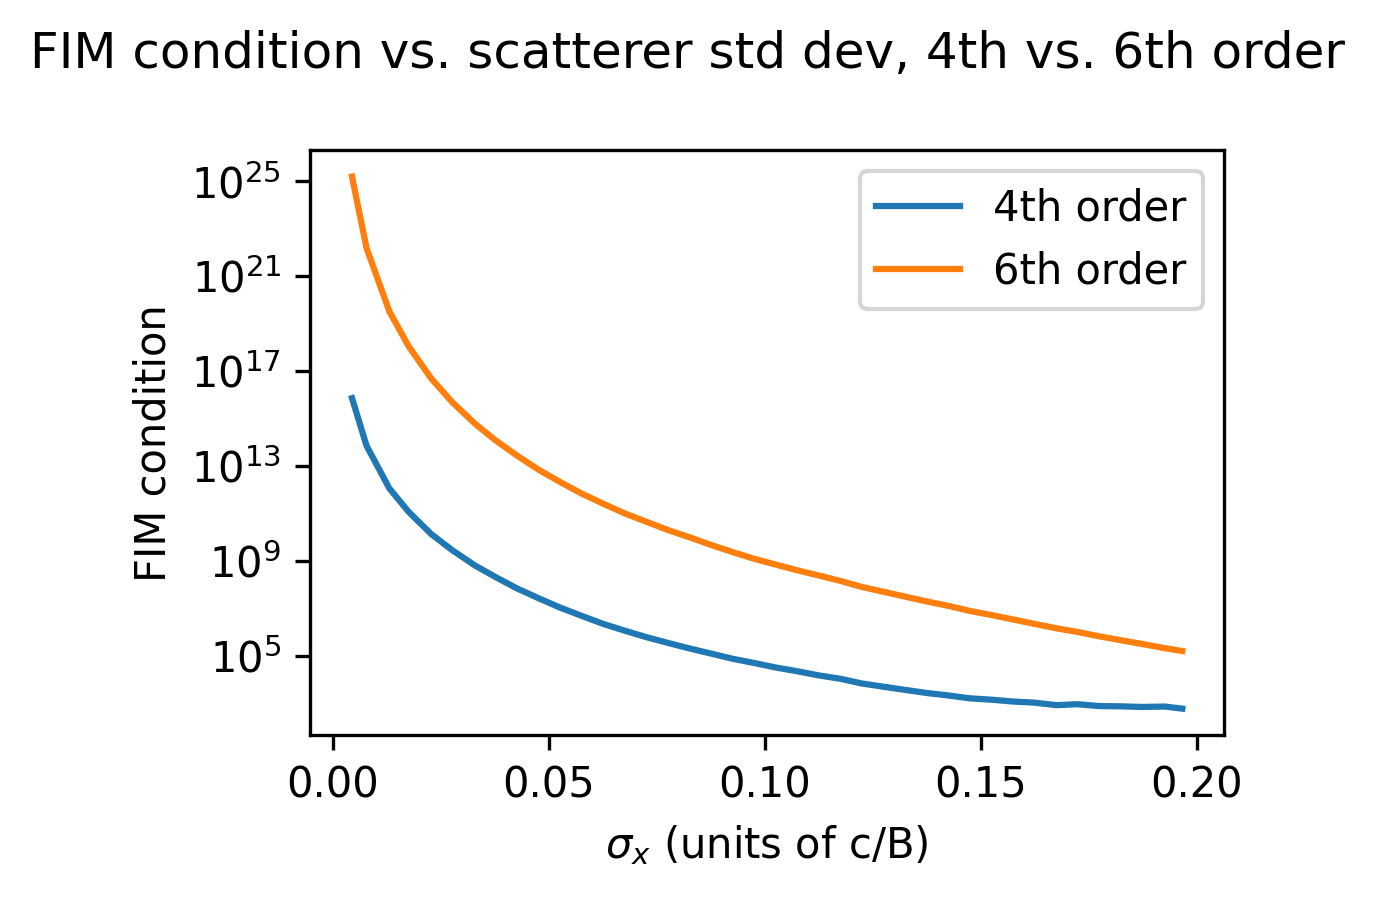

In [23]:
df_array    = []
orders      = [4, 6]
for order in orders:
    df_array.append(f'delta_discrete_len20_snr20_order{order}_crlb.csv')

fim_condition(CRLB_DIR, df_array, orders)